In [15]:
import pandas as pd
rankings = pd.read_csv('scientific_journal_ranking_2024.csv', delimiter=';')

In [16]:
rankings.head()

,Rank,Sourceid,Title,Type,Issn,Publisher,Open Access,Open Access Diamond,SJR,SJR Best Quartile,...,Ref. / Doc.,%Female,Overton,SDG,Country,Region,Publisher.1,Coverage,Categories,Areas
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235",John Wiley and Sons Inc,No,No,"145,004",Q1,...,"62,88","48,21",4,37,United States,Northern America,John Wiley and Sons Inc,1950-2025,Hematology (Q1); Oncology (Q1),Medicine
1,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601",Centers for Disease Control and Prevention (CDC),Yes,No,"41,754",Q1,...,"275,33","75,93",1,5,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2024,Epidemiology (Q1); Health Information Manageme...,Environmental Science; Health Professions; Med...
2,3,20315,Nature Reviews Molecular Cell Biology,journal,"14710072, 14710080",Nature Research,No,No,"37,353",Q1,...,"92,45","41,22",0,15,United Kingdom,Western Europe,Nature Research,2000-2025,Cell Biology (Q1); Molecular Biology (Q1),"Biochemistry, Genetics and Molecular Biology"
3,4,29431,Quarterly Journal of Economics,journal,"00335533, 15314650",Oxford University Press,No,No,"35,995",Q1,...,"69,79","25,18",35,27,United Kingdom,Western Europe,Oxford University Press,1886-2025,Economics and Econometrics (Q1),"Economics, Econometrics and Finance"
4,5,20425,Nature Reviews Drug Discovery,journal,"14741784, 14741776",Nature Research,No,No,"30,506",Q1,...,"35,66","26,67",1,58,United Kingdom,Western Europe,Nature Research,2002-2025,Drug Discovery (Q1); Medicine (miscellaneous) ...,"Medicine; Pharmacology, Toxicology and Pharmac..."


In [17]:
import pandas as pd
import re

# Step 1: Parse the Categories Column
# Let's first examine what we're working with

def examine_categories(df, num_samples=10):
    """
    Examine sample categories to understand the format
    """
    print("=" * 80)
    print("SAMPLE CATEGORIES FROM DATASET")
    print("=" * 80)
    
    samples = df['Categories'].dropna().head(num_samples)
    for idx, cat in enumerate(samples, 1):
        print(f"\n{idx}. {cat}")
    
    return samples


def parse_single_category_string(category_string):
    """
    Parse a single category string into a list of (category, quartile) tuples
    
    Parameters:
    -----------
    category_string : str
        String like "Hematology (Q1); Oncology (Q1)"
    
    Returns:
    --------
    list of tuples
        [(category_name, quartile), ...] e.g., [('Hematology', 'Q1'), ('Oncology', 'Q1')]
    """
    if pd.isna(category_string):
        return []
    
    # Split by semicolon
    categories = category_string.split(';')
    parsed_categories = []
    
    for cat in categories:
        cat = cat.strip()
        
        # Extract category name and quartile using regex
        # Pattern: anything followed by (Q1), (Q2), (Q3), or (Q4)
        match = re.search(r'^(.*?)\s*\(([Q][1-4])\)\s*$', cat)
        
        if match:
            category_name = match.group(1).strip()
            quartile = match.group(2).strip()
            parsed_categories.append((category_name, quartile))
        else:
            # If no quartile found, still include the category with None as quartile
            if cat:  # Only if not empty
                parsed_categories.append((cat, None))
            else:
                print("f'Warning : Could not parse :,{cat}'")
    
    return parsed_categories


def test_parsing(df, num_tests=5):
    """
    Test the parsing function on sample data
    """
    print("\n" + "=" * 80)
    print("TESTING CATEGORY PARSING")
    print("=" * 80)
    
    samples = df['Categories'].dropna().head(num_tests)
    
    for idx, cat_string in enumerate(samples, 1):
        print(f"\n{idx}. Original:")
        print(f"   {cat_string}")
        
        parsed = parse_single_category_string(cat_string)
        print(f"   Parsed into {len(parsed)} categories:")
        for cat_name, quartile in parsed:
            print(f"   - Category: '{cat_name}' | Quartile: '{quartile}'")

test_parsing(rankings)


TESTING CATEGORY PARSING

1. Original:
   Hematology (Q1); Oncology (Q1)
   Parsed into 2 categories:
   - Category: 'Hematology' | Quartile: 'Q1'
   - Category: 'Oncology' | Quartile: 'Q1'

2. Original:
   Epidemiology (Q1); Health Information Management (Q1); Health (social science) (Q1); Health, Toxicology and Mutagenesis (Q1); Medicine (miscellaneous) (Q1)
   Parsed into 5 categories:
   - Category: 'Epidemiology' | Quartile: 'Q1'
   - Category: 'Health Information Management' | Quartile: 'Q1'
   - Category: 'Health (social science)' | Quartile: 'Q1'
   - Category: 'Health, Toxicology and Mutagenesis' | Quartile: 'Q1'
   - Category: 'Medicine (miscellaneous)' | Quartile: 'Q1'

3. Original:
   Cell Biology (Q1); Molecular Biology (Q1)
   Parsed into 2 categories:
   - Category: 'Cell Biology' | Quartile: 'Q1'
   - Category: 'Molecular Biology' | Quartile: 'Q1'

4. Original:
   Economics and Econometrics (Q1)
   Parsed into 1 categories:
   - Category: 'Economics and Econometrics' |

In [18]:
def explode_categories(df):
    """
    Transform the dataframe from wide to long format.
    Each journal will have one row per category it belongs to.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Original dataframe with Categories column
    
    Returns:
    --------
    pandas DataFrame
        Exploded dataframe with separate Category and Quartile columns
    """
    print("Starting explosion process...")
    print(f"Original dataframe shape: {df.shape}")
    
    # Create a list to store all the new rows
    exploded_rows = []
    
    # Process each journal (row)
    for idx, row in df.iterrows():
        # Parse the categories for this journal
        parsed_cats = parse_single_category_string(row['Categories'])
        
        if parsed_cats:
            # Create a new row for each category
            for category_name, quartile in parsed_cats:
                new_row = row.copy()
                new_row['Category'] = category_name
                new_row['Quartile'] = quartile
                exploded_rows.append(new_row)
        else:
            # If no categories, keep the row but with NaN for Category and Quartile
            new_row = row.copy()
            new_row['Category'] = None
            new_row['Quartile'] = None
            exploded_rows.append(new_row)
    
    # Create the new dataframe
    df_exploded = pd.DataFrame(exploded_rows)
    
    print(f"Exploded dataframe shape: {df_exploded.shape}")
    print(f"Number of rows increased by: {df_exploded.shape[0] - df.shape[0]}")
    
    # Reset index
    df_exploded = df_exploded.reset_index(drop=True)
    
    return df_exploded


def compare_before_after(df_original, df_exploded, journal_title=None):
    """
    Compare a specific journal before and after explosion to verify the transformation
    
    Parameters:
    -----------
    df_original : pandas DataFrame
        Original dataframe before explosion
    df_exploded : pandas DataFrame
        Exploded dataframe after transformation
    journal_title : str, optional
        Title of journal to compare. If None, uses first journal.
    """
    if journal_title is None:
        # Use the first journal as example
        journal_title = df_original.iloc[0]['Title']
    
    print("\n" + "=" * 80)
    print(f"COMPARISON FOR: {journal_title}")
    print("=" * 80)
    
    # Original
    print("\nORIGINAL (1 row):")
    original = df_original[df_original['Title'] == journal_title]
    if not original.empty:
        print(f"  Rank: {original.iloc[0]['Rank']}")
        print(f"  Categories: {original.iloc[0]['Categories']}")
    
    # Exploded
    print("\nEXPLODED (multiple rows):")
    exploded = df_exploded[df_exploded['Title'] == journal_title]
    print(f"  Number of rows: {len(exploded)}")
    for idx, row in exploded.iterrows():
        print(f"  - Rank: {row['Rank']} | Category: {row['Category']} | Quartile: {row['Quartile']}")


def show_statistics(df_exploded):
    """
    Show useful statistics about the exploded dataframe
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe with Category and Quartile columns
    """
    print("\n" + "=" * 80)
    print("STATISTICS")
    print("=" * 80)
    
    # Number of unique categories
    n_categories = df_exploded['Category'].nunique()
    print(f"\nTotal unique categories: {n_categories}")
    
    # Categories without quartile info
    missing_quartile = df_exploded['Quartile'].isna().sum()
    print(f"Rows with missing quartile: {missing_quartile}")
    
    # Quartile distribution
    print("\nQuartile distribution:")
    print(df_exploded['Quartile'].value_counts(dropna=False).sort_index())
    
    # Top 10 most common categories
    print("\nTop 10 most common categories:")
    print(df_exploded['Category'].value_counts().head(10))
    
    # Journals per category (average)
    avg_journals = len(df_exploded) / n_categories
    print(f"\nAverage journals per category: {avg_journals:.1f}")


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

print("=" * 80)
print("STEP 2: EXPLODE CATEGORIES - COMPLETE CODE")
print("=" * 80)
print("\nTo use this code:")
print("\n1. Load your dataframe:")
print("   df = pd.read_csv('your_file.csv')")
print("\n2. Create exploded dataframe:")
print("   df_exploded = explode_categories(df)")
print("\n3. Compare before and after:")
print("   compare_before_after(df, df_exploded)")
print("   # Or for specific journal:")
print("   compare_before_after(df, df_exploded, 'Ca-A Cancer Journal for Clinicians')")
print("\n4. Show statistics:")
print("   show_statistics(df_exploded)")
print("\n5. Save if needed:")
print("   df_exploded.to_csv('journals_exploded.csv', index=False)")

STEP 2: EXPLODE CATEGORIES - COMPLETE CODE

To use this code:

1. Load your dataframe:
   df = pd.read_csv('your_file.csv')

2. Create exploded dataframe:
   df_exploded = explode_categories(df)

3. Compare before and after:
   compare_before_after(df, df_exploded)
   # Or for specific journal:
   compare_before_after(df, df_exploded, 'Ca-A Cancer Journal for Clinicians')

4. Show statistics:
   show_statistics(df_exploded)

5. Save if needed:
   df_exploded.to_csv('journals_exploded.csv', index=False)


Here's a comprehensive summary of the code and data analysis:

### Data Overview
- Working with scientific journal rankings data from 2024
- Source data includes journals with their categories and quartile rankings (Q1-Q4)
- Each journal can belong to multiple categories with different quartile rankings

### Major Data Transformations

1. **Initial Data Loading**


- Loaded CSV data with delimiter ';'
- Original format: one row per journal with concatenated categories



2. **Category Parsing and Explosion**
- Developed functions to parse category strings with quartile information
- Transformed data from wide to long format (exploded)
- Each journal-category combination became a separate row
- Added distinct Category and Quartile columns

3. **Analysis Functions**

#### Basic Statistics
- Created functions for:
  - Top journals by category
  - Q1 journals filtering
  - Category searching
  - Journal category lookup
  - Category summaries

#### Visualization Tools
- Implemented various plots:
  - Journals per category
  - Quartile distribution
  - Ranking boxplots
  - Category comparisons
  - Co-occurrence heatmaps

#### Advanced Analysis
- **Category Co-occurrence Analysis**
  - Pairs and triplets identification
  - Frequency analysis of category combinations
  - Co-occurrence matrix creation

- **Category Behavior Analysis**
  - Classification of categories as:
    - Isolated
    - Highly Specialized
    - Moderately Specialized
    - Moderately General
    - Highly General

### Key Features

1. **Search and Query**
- Category search functionality
- Journal lookup across categories
- Quartile-based filtering

2. **Statistical Analysis**
- Ranking distributions
- Quartile breakdowns
- Category relationships

3. **Visualization**
- Multiple plot types for different aspects
- Interactive data exploration
- Comparative visualizations

4. **Grouping Strategy**
- Category relationship identification
- Suggested grouping based on co-occurrence
- Strong link analysis

### Data Insights
- Categories can be classified by their pairing behavior
- Some categories are highly specialized, others more general
- Clear patterns in category co-occurrences
- Quartile distributions vary significantly across categories

### Purpose
This codebase provides a comprehensive toolkit for:
- Understanding journal categorization
- Analyzing scientific field relationships
- Supporting journal selection decisions
- Identifying related research areas

The code is structured to support both exploratory analysis and specific queries, making it valuable for both research planning and bibliometric analysis.

In [19]:
rankings_exploded = explode_categories(rankings)
compare_before_after(rankings, rankings_exploded)

Starting explosion process...
Original dataframe shape: (31136, 27)
Exploded dataframe shape: (76823, 29)
Number of rows increased by: 45687

COMPARISON FOR: Ca-A Cancer Journal for Clinicians

ORIGINAL (1 row):
  Rank: 1
  Categories: Hematology (Q1); Oncology (Q1)

EXPLODED (multiple rows):
  Number of rows: 2
  - Rank: 1 | Category: Hematology | Quartile: Q1
  - Rank: 1 | Category: Oncology | Quartile: Q1


In [20]:
show_statistics(rankings_exploded)



STATISTICS

Total unique categories: 310
Rows with missing quartile: 2691

Quartile distribution:
Quartile
Q1      18570
Q2      18556
Q3      18513
Q4      18493
None     2691
Name: count, dtype: int64

Top 10 most common categories:
Category
Medicine (miscellaneous)                 2524
History                                  1863
Education                                1597
Sociology and Political Science          1461
Cultural Studies                         1398
Linguistics and Language                 1373
Literature and Literary Theory           1182
Law                                      1089
Electrical and Electronic Engineering     985
Computer Science Applications             952
Name: count, dtype: int64

Average journals per category: 247.8


In [21]:
rankings_exploded.head()

,Rank,Sourceid,Title,Type,Issn,Publisher,Open Access,Open Access Diamond,SJR,SJR Best Quartile,...,Overton,SDG,Country,Region,Publisher.1,Coverage,Categories,Areas,Category,Quartile
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235",John Wiley and Sons Inc,No,No,"145,004",Q1,...,4,37,United States,Northern America,John Wiley and Sons Inc,1950-2025,Hematology (Q1); Oncology (Q1),Medicine,Hematology,Q1
1,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235",John Wiley and Sons Inc,No,No,"145,004",Q1,...,4,37,United States,Northern America,John Wiley and Sons Inc,1950-2025,Hematology (Q1); Oncology (Q1),Medicine,Oncology,Q1
2,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601",Centers for Disease Control and Prevention (CDC),Yes,No,"41,754",Q1,...,1,5,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2024,Epidemiology (Q1); Health Information Manageme...,Environmental Science; Health Professions; Med...,Epidemiology,Q1
3,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601",Centers for Disease Control and Prevention (CDC),Yes,No,"41,754",Q1,...,1,5,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2024,Epidemiology (Q1); Health Information Manageme...,Environmental Science; Health Professions; Med...,Health Information Management,Q1
4,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601",Centers for Disease Control and Prevention (CDC),Yes,No,"41,754",Q1,...,1,5,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2024,Epidemiology (Q1); Health Information Manageme...,Environmental Science; Health Professions; Med...,Health (social science),Q1


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Visualization and Analysis Functions

def plot_journals_per_category(df_exploded, top_n=20, figsize=(12, 8)):
    """
    Plot the number of journals per category
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe with Category column
    top_n : int
        Number of top categories to show
    figsize : tuple
        Figure size (width, height)
    """
    # Count journals per category
    category_counts = df_exploded['Category'].value_counts().head(top_n)
    
    # Create the plot
    plt.figure(figsize=figsize)
    category_counts.plot(kind='barh', color='steelblue')
    plt.xlabel('Number of Journals', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.title(f'Top {top_n} Categories by Number of Journals', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()  # Highest at top
    plt.tight_layout()
    plt.grid(axis='x', alpha=0.3)
    plt.show()
    
    return category_counts


def plot_quartile_distribution_by_category(df_exploded, categories=None, figsize=(14, 8)):
    """
    Plot quartile distribution for specific categories
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe with Category and Quartile columns
    categories : list, optional
        List of categories to analyze. If None, uses top 10 categories.
    figsize : tuple
        Figure size (width, height)
    """
    # If no categories specified, use top 10
    if categories is None:
        categories = df_exploded['Category'].value_counts().head(10).index.tolist()
    
    # Filter data for selected categories and remove rows with missing quartile
    df_filtered = df_exploded[
        (df_exploded['Category'].isin(categories)) & 
        (df_exploded['Quartile'].notna())
    ]
    
    # Create crosstab for quartile distribution
    quartile_dist = pd.crosstab(
        df_filtered['Category'], 
        df_filtered['Quartile'], 
        normalize='index'
    ) * 100  # Convert to percentage
    
    # Reorder columns to Q1, Q2, Q3, Q4
    quartile_dist = quartile_dist[['Q1', 'Q2', 'Q3', 'Q4']]
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=figsize)
    quartile_dist.plot(
        kind='barh', 
        stacked=True, 
        ax=ax,
        color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    )
    
    plt.xlabel('Percentage (%)', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.title('Quartile Distribution by Category', fontsize=14, fontweight='bold')
    plt.legend(title='Quartile', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return quartile_dist


def analyze_category_rankings(df_exploded, category_name, top_n=10):
    """
    Analyze and display top journals in a specific category
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    category_name : str
        Name of the category to analyze
    top_n : int
        Number of top journals to show
    """
    # Filter for the specific category
    df_category = df_exploded[df_exploded['Category'] == category_name].copy()
    
    if df_category.empty:
        print(f"No journals found for category: {category_name}")
        return None
    
    # Sort by rank
    df_category = df_category.sort_values('Rank')
    
    print("\n" + "=" * 80)
    print(f"CATEGORY ANALYSIS: {category_name}")
    print("=" * 80)
    
    # Summary statistics
    print(f"\nTotal journals in this category: {len(df_category)}")
    print(f"\nQuartile distribution:")
    print(df_category['Quartile'].value_counts().sort_index())
    
    # Top N journals
    print(f"\n{'='*80}")
    print(f"TOP {top_n} JOURNALS IN {category_name}")
    print(f"{'='*80}\n")
    
    top_journals = df_category.head(top_n)
    
    for idx, row in top_journals.iterrows():
        print(f"{row['Rank']:4d}. {row['Title']}")
        print(f"      Quartile: {row['Quartile']} | SJR: {row['SJR']} | Country: {row['Country']}")
        print()
    
    return df_category


def compare_categories(df_exploded, categories, metric='Rank'):
    """
    Compare multiple categories side by side
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    categories : list
        List of category names to compare
    metric : str
        Metric to compare ('Rank', 'SJR', etc.)
    """
    print("\n" + "=" * 80)
    print(f"COMPARING CATEGORIES")
    print("=" * 80)
    
    comparison_data = []
    
    for cat in categories:
        df_cat = df_exploded[df_exploded['Category'] == cat]
        
        if not df_cat.empty:
            data = {
                'Category': cat,
                'Total Journals': len(df_cat),
                'Q1 Journals': len(df_cat[df_cat['Quartile'] == 'Q1']),
                'Q2 Journals': len(df_cat[df_cat['Quartile'] == 'Q2']),
                'Q3 Journals': len(df_cat[df_cat['Quartile'] == 'Q3']),
                'Q4 Journals': len(df_cat[df_cat['Quartile'] == 'Q4']),
                'Best Rank': df_cat['Rank'].min(),
                'Median Rank': df_cat['Rank'].median()
            }
            comparison_data.append(data)
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("\n", df_comparison.to_string(index=False))
    
    return df_comparison


def plot_category_comparison(df_exploded, categories, figsize=(12, 6)):
    """
    Visual comparison of quartile distribution across categories
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    categories : list
        List of categories to compare
    figsize : tuple
        Figure size
    """
    comparison_data = []
    
    for cat in categories:
        df_cat = df_exploded[
            (df_exploded['Category'] == cat) & 
            (df_exploded['Quartile'].notna())
        ]
        
        quartile_counts = df_cat['Quartile'].value_counts()
        for q in ['Q1', 'Q2', 'Q3', 'Q4']:
            comparison_data.append({
                'Category': cat,
                'Quartile': q,
                'Count': quartile_counts.get(q, 0)
            })
    
    df_plot = pd.DataFrame(comparison_data)
    
    # Create grouped bar chart
    fig, ax = plt.subplots(figsize=figsize)
    
    # Pivot for plotting
    df_pivot = df_plot.pivot(index='Category', columns='Quartile', values='Count')
    df_pivot = df_pivot[['Q1', 'Q2', 'Q3', 'Q4']]
    
    df_pivot.plot(
        kind='bar', 
        ax=ax,
        color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    )
    
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Number of Journals', fontsize=12)
    plt.title('Quartile Distribution Comparison', fontsize=14, fontweight='bold')
    plt.legend(title='Quartile')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

print("=" * 80)
print("STEP 3: VISUALIZATION AND ANALYSIS - COMPLETE CODE")
print("=" * 80)
print("\nAvailable functions:")
print("\n1. plot_journals_per_category(df_exploded, top_n=20)")
print("   - Bar chart showing number of journals per category")
print("\n2. plot_quartile_distribution_by_category(df_exploded, categories=None)")
print("   - Stacked bar chart showing quartile distribution")
print("\n3. analyze_category_rankings(df_exploded, 'Medicine (miscellaneous)', top_n=10)")
print("   - Detailed analysis of a specific category")
print("\n4. compare_categories(df_exploded, ['Medicine (miscellaneous)', 'Education'])")
print("   - Side-by-side comparison of multiple categories")
print("\n5. plot_category_comparison(df_exploded, ['Medicine (miscellaneous)', 'Education'])")
print("   - Visual comparison of categories")
print("\n" + "=" * 80)
print("\nEXAMPLE USAGE:")
print("=" * 80)
print("""
# Plot top 20 categories by journal count
plot_journals_per_category(rankings_exploded, top_n=20)

# Show quartile distribution for top 10 categories
plot_quartile_distribution_by_category(rankings_exploded)

# Analyze a specific category
analyze_category_rankings(rankings_exploded, 'Computer Science Applications', top_n=10)

# Compare multiple categories
compare_categories(rankings_exploded, [
    'Medicine (miscellaneous)', 
    'Computer Science Applications',
    'Education'
])

# Visual comparison
plot_category_comparison(rankings_exploded, [
    'Medicine (miscellaneous)', 
    'Computer Science Applications',
    'Education'
])
""")

STEP 3: VISUALIZATION AND ANALYSIS - COMPLETE CODE

Available functions:

1. plot_journals_per_category(df_exploded, top_n=20)
   - Bar chart showing number of journals per category

2. plot_quartile_distribution_by_category(df_exploded, categories=None)
   - Stacked bar chart showing quartile distribution

3. analyze_category_rankings(df_exploded, 'Medicine (miscellaneous)', top_n=10)
   - Detailed analysis of a specific category

4. compare_categories(df_exploded, ['Medicine (miscellaneous)', 'Education'])
   - Side-by-side comparison of multiple categories

5. plot_category_comparison(df_exploded, ['Medicine (miscellaneous)', 'Education'])
   - Visual comparison of categories


EXAMPLE USAGE:

# Plot top 20 categories by journal count
plot_journals_per_category(rankings_exploded, top_n=20)

# Show quartile distribution for top 10 categories
plot_quartile_distribution_by_category(rankings_exploded)

# Analyze a specific category
analyze_category_rankings(rankings_exploded, 'Computer 

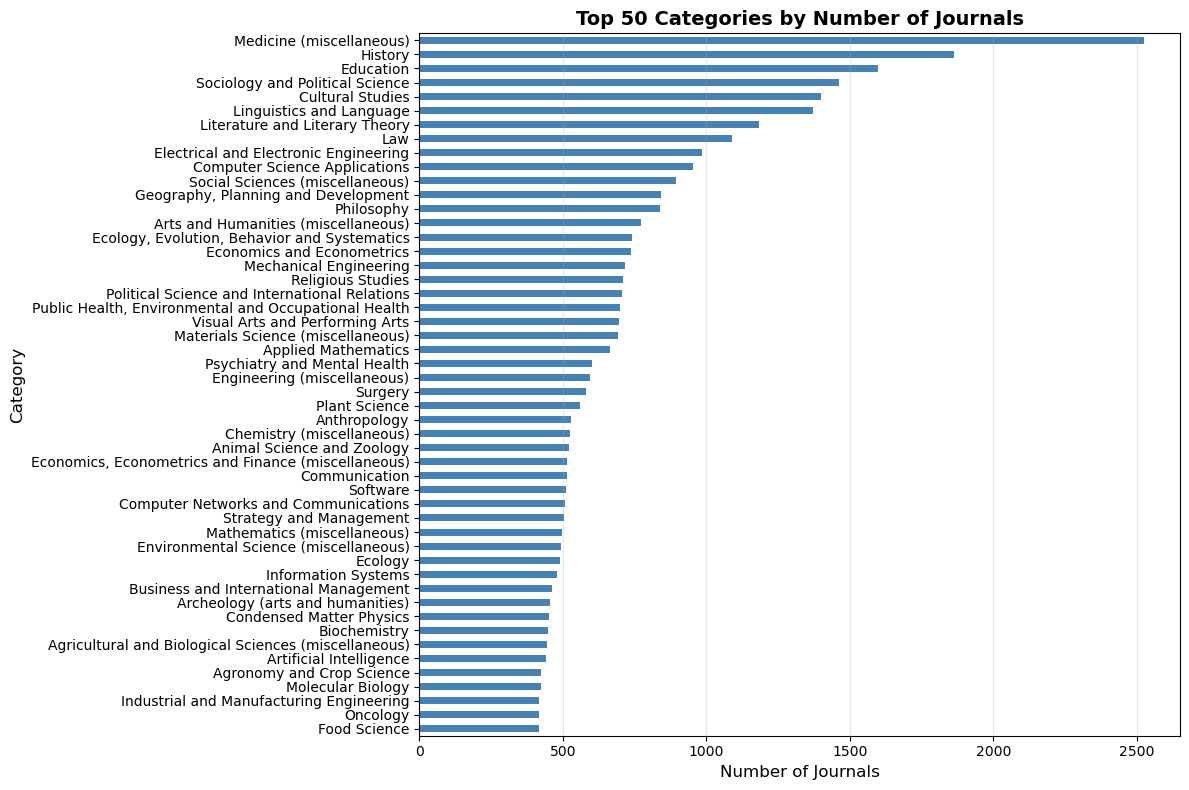

Category
Medicine (miscellaneous)                                2524
History                                                 1863
Education                                               1597
Sociology and Political Science                         1461
Cultural Studies                                        1398
Linguistics and Language                                1373
Literature and Literary Theory                          1182
Law                                                     1089
Electrical and Electronic Engineering                    985
Computer Science Applications                            952
Social Sciences (miscellaneous)                          893
Geography, Planning and Development                      842
Philosophy                                               838
Arts and Humanities (miscellaneous)                      773
Ecology, Evolution, Behavior and Systematics             742
Economics and Econometrics                               738
Mechanical Engi

In [23]:
plot_journals_per_category(rankings_exploded, top_n=50)

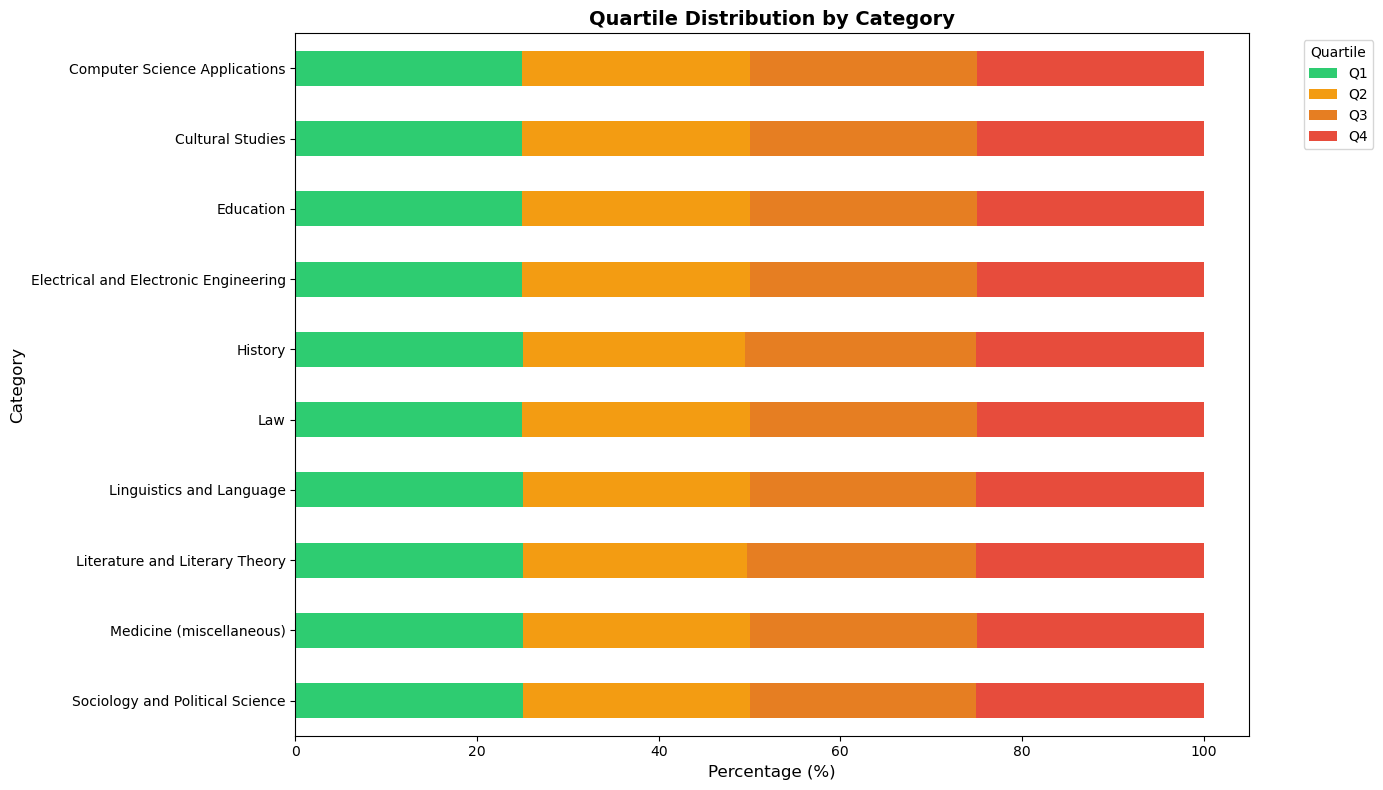

Quartile,Q1,Q2,Q3,Q4
Category,,,,
Computer Science Applications,25.000000,25.000000,25.000000,25.000000
Cultural Studies,25.000000,25.000000,25.000000,25.000000
Education,25.000000,25.000000,25.000000,25.000000
Electrical and Electronic Engineering,25.000000,25.000000,25.000000,25.000000
History,25.013594,24.469821,25.502991,25.013594
Law,25.000000,25.000000,25.000000,25.000000
Linguistics and Language,25.018560,25.018560,24.944321,25.018560
Literature and Literary Theory,25.021422,24.678663,25.278492,25.021422
Medicine (miscellaneous),25.019984,24.980016,25.019984,24.980016


In [24]:
plot_quartile_distribution_by_category(rankings_exploded)


In [25]:
analyze_category_rankings(rankings_exploded, 'Information Systems', top_n=10)



CATEGORY ANALYSIS: Information Systems

Total journals in this category: 481

Quartile distribution:
Quartile
Q1    100
Q2    100
Q3    100
Q4    100
Name: count, dtype: int64

TOP 10 JOURNALS IN Information Systems

 194. International Journal of Information Management
      Quartile: Q1 | SJR: 6,260 | Country: United Kingdom

 208. Journal of Service Research
      Quartile: Q1 | SJR: 6,011 | Country: United States

 304. Information Systems Research
      Quartile: Q1 | SJR: 4,850 | Country: United States

 310. Molecular Systems Biology
      Quartile: Q1 | SJR: 4,783 | Country: United Kingdom

 331. Journal of Supply Chain Management
      Quartile: Q1 | SJR: 4,562 | Country: United States

 347. MIS Quarterly: Management Information Systems
      Quartile: Q1 | SJR: 4,486 | Country: United States

 354. IEEE Transactions on Cybernetics
      Quartile: Q1 | SJR: 4,450 | Country: United States

 393. Information Fusion
      Quartile: Q1 | SJR: 4,128 | Country: Netherlands

 457. 

,Rank,Sourceid,Title,Type,Issn,Publisher,Open Access,Open Access Diamond,SJR,SJR Best Quartile,...,Overton,SDG,Country,Region,Publisher.1,Coverage,Categories,Areas,Category,Quartile
443,194,15631,International Journal of Information Management,journal,02684012,Elsevier Ltd,No,No,"6,260",Q1,...,2,14,United Kingdom,Western Europe,Elsevier Ltd,"1970, 1986-2025",Artificial Intelligence (Q1); Computer Network...,"Business, Management and Accounting; Computer ...",Information Systems,Q1
476,208,144974,Journal of Service Research,journal,"10946705, 15527379",SAGE Publications Inc.,No,No,"6,011",Q1,...,0,14,United States,Northern America,SAGE Publications Inc.,1998-2025,Information Systems (Q1); Organizational Behav...,"Business, Management and Accounting; Computer ...",Information Systems,Q1
727,304,15574,Information Systems Research,journal,"15265536, 10477047",INFORMS Institute for Operations Research and ...,No,No,"4,850",Q1,...,1,22,United States,Northern America,INFORMS Institute for Operations Research and ...,1990-2024,Computer Networks and Communications (Q1); Inf...,"Business, Management and Accounting; Computer ...",Information Systems,Q1
747,310,4700152228,Molecular Systems Biology,journal,17444292,Springer Science and Business Media Deutschlan...,Yes,No,"4,783",Q1,...,0,20,United Kingdom,Western Europe,Springer Science and Business Media Deutschlan...,2005-2025,Agricultural and Biological Sciences (miscella...,Agricultural and Biological Sciences; Biochemi...,Information Systems,Q1
792,331,100147317,Journal of Supply Chain Management,journal,"15232409, 1745493X",Wiley-Blackwell,No,No,"4,562",Q1,...,1,5,United States,Northern America,Wiley-Blackwell,1999-2025,"Economics, Econometrics and Finance (miscellan...","Business, Management and Accounting; Computer ...",Information Systems,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76564,31041,21101261587,Memorias de la Conferencia Iberoamericana de C...,conference and proceedings,27716333,NaN,No,No,NaN,-,...,0,17,United States,Northern America,NaN,2024,Artificial Intelligence; Computer Networks and...,Computer Science,Information Systems,None
76658,31074,21101258747,Proceedings - Swiss Conference on Data Science...,journal,"28353412, 28353420",Institute of Electrical and Electronics Engine...,No,No,NaN,-,...,0,10,United States,Northern America,Institute of Electrical and Electronics Engine...,2024,Artificial Intelligence; Information Systems; ...,Computer Science; Decision Sciences,Information Systems,None
76681,31081,21101260450,Proceedings of the IEEE International Conferen...,journal,"28363868, 28363876",Institute of Electrical and Electronics Engine...,No,No,NaN,-,...,0,17,United States,Northern America,Institute of Electrical and Electronics Engine...,2024,Artificial Intelligence; Computer Networks and...,Computer Science; Decision Sciences,Information Systems,None
76698,31086,21101260301,Proceedings of the International Conference on...,journal,"27704327, 27704319",Institute of Electrical and Electronics Engine...,No,No,NaN,-,...,0,12,United States,Northern America,Institute of Electrical and Electronics Engine...,2024,Artificial Intelligence; Computer Science Appl...,Computer Science; Engineering,Information Systems,None


In [26]:
# Compare multiple categories
compare_categories(rankings_exploded, [
    'Medicine (miscellaneous)', 
    'Computer Science Applications',
    'Education'
])


COMPARING CATEGORIES

                      Category  Total Journals  Q1 Journals  Q2 Journals  Q3 Journals  Q4 Journals  Best Rank  Median Rank
     Medicine (miscellaneous)            2524          626          625          626          625          2      11155.0
Computer Science Applications             952          205          205          205          205         86      13619.5
                    Education            1597          389          389          389          389        276      14604.0


,Category,Total Journals,Q1 Journals,Q2 Journals,Q3 Journals,Q4 Journals,Best Rank,Median Rank
0,Medicine (miscellaneous),2524,626,625,626,625,2,11155.0
1,Computer Science Applications,952,205,205,205,205,86,13619.5
2,Education,1597,389,389,389,389,276,14604.0


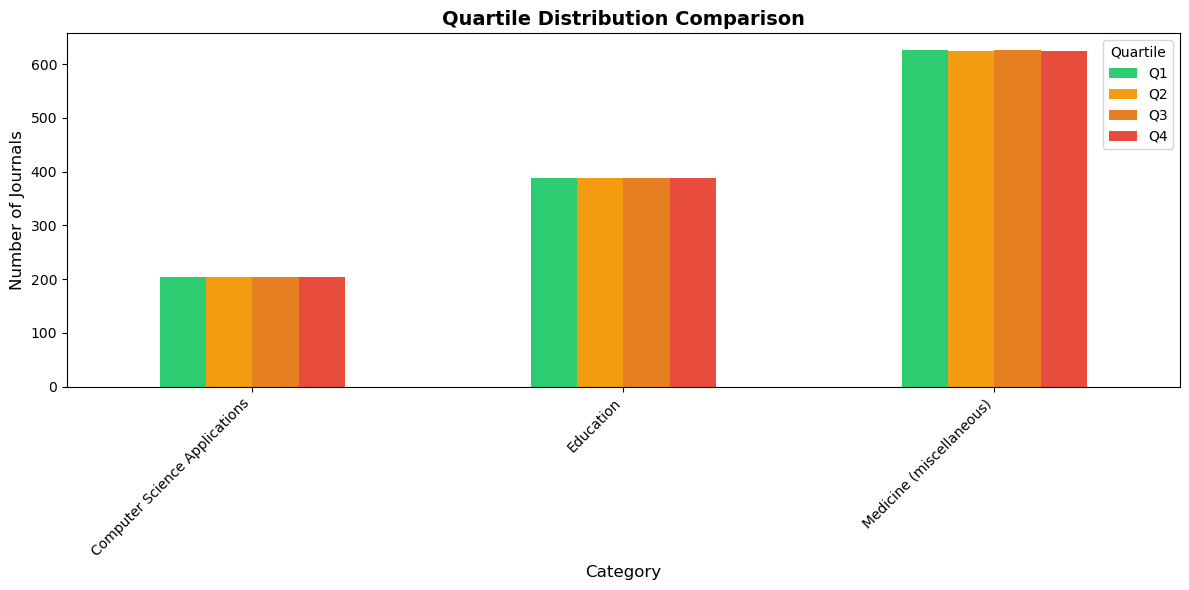

In [27]:
plot_category_comparison(rankings_exploded, [
    'Medicine (miscellaneous)', 
    'Computer Science Applications',
    'Education'
])

In [28]:
def plot_ranking_boxplot_by_category(df_exploded, categories=None, top_n=15, figsize=(14, 8)):
    """
    Plot boxplot of journal rankings per category
    Shows the distribution of rankings within each category
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe with Category and Rank columns
    categories : list, optional
        List of specific categories to plot. If None, uses top N categories.
    top_n : int
        Number of top categories to show (if categories is None)
    figsize : tuple
        Figure size (width, height)
    """
    # If no categories specified, use top N by journal count
    if categories is None:
        categories = df_exploded['Category'].value_counts().head(top_n).index.tolist()
    
    # Filter data for selected categories
    df_filtered = df_exploded[df_exploded['Category'].isin(categories)].copy()
    
    # Sort categories by median rank (best journals first)
    category_medians = df_filtered.groupby('Category')['Rank'].median().sort_values()
    sorted_categories = category_medians.index.tolist()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot
    df_filtered['Category'] = pd.Categorical(
        df_filtered['Category'], 
        categories=sorted_categories, 
        ordered=True
    )
    
    df_filtered.boxplot(
        column='Rank',
        by='Category',
        ax=ax,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray'),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5)
    )
    
    plt.xlabel('Journal Rank (lower is better)', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.title('Distribution of Journal Rankings by Category', fontsize=14, fontweight='bold')
    plt.suptitle('')  # Remove automatic title
    
    # Invert x-axis so best ranks (lowest numbers) are on the right
    ax.invert_xaxis()
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "=" * 80)
    print("RANKING STATISTICS BY CATEGORY")
    print("=" * 80)
    print(f"\n{'Category':<40} {'Min':<8} {'Q1':<8} {'Median':<8} {'Q3':<8} {'Max':<8}")
    print("-" * 80)
    
    for cat in sorted_categories:
        ranks = df_filtered[df_filtered['Category'] == cat]['Rank']
        print(f"{cat:<40} {ranks.min():<8} {ranks.quantile(0.25):<8.0f} "
              f"{ranks.median():<8.0f} {ranks.quantile(0.75):<8.0f} {ranks.max():<8}")
    
    return df_filtered[['Category', 'Rank']].groupby('Category').describe()



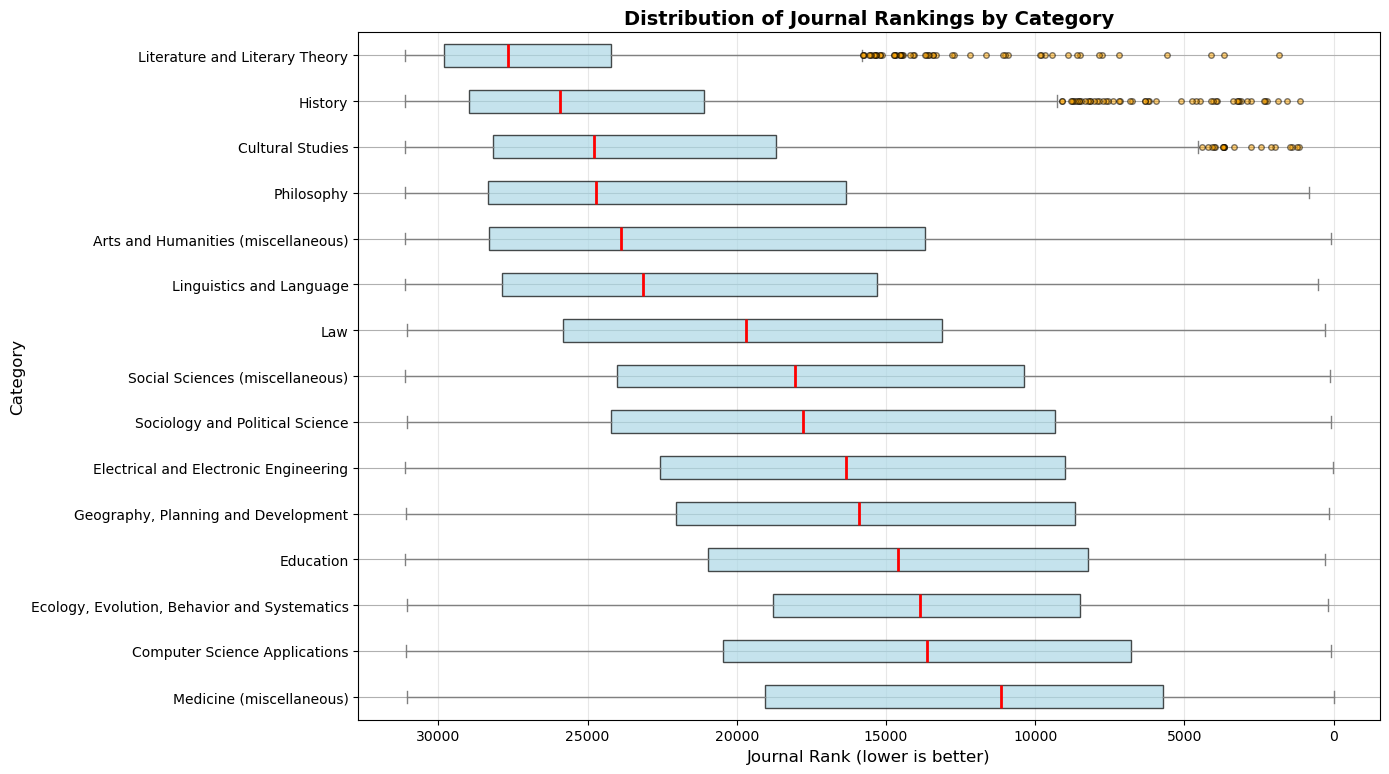


RANKING STATISTICS BY CATEGORY

Category                                 Min      Q1       Median   Q3       Max     
--------------------------------------------------------------------------------
Medicine (miscellaneous)                 2        5715     11155    19066    31063   
Computer Science Applications            86       6783     13620    20458    31098   
Ecology, Evolution, Behavior and Systematics 186      8516     13876    18791    31060   
Education                                276      8224     14604    20963    31126   
Geography, Planning and Development      151      8660     15918    22024    31102   
Electrical and Electronic Engineering    37       9004     16349    22561    31112   
Sociology and Political Science          80       9321     17773    24223    31068   
Social Sciences (miscellaneous)          127      10364    18059    24021    31123   
Law                                      296      13128    19695    25816    31062   
Linguistics and Langua

/var/folders/c8/ypmvlrjd3r16wxnxns1rljyr0000gn/T/ipykernel_54671/4190051197.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_filtered[['Category', 'Rank']].groupby('Category').describe()


Rank                \
                                               count          mean   
Category                                                             
Medicine (miscellaneous)                      2524.0  12752.671949   
Computer Science Applications                  952.0  13933.715336   
Ecology, Evolution, Behavior and Systematics   742.0  13635.216981   
Education                                     1597.0  14736.200376   
Geography, Planning and Development            842.0  15432.743468   
Electrical and Electronic Engineering          985.0  15637.205076   
Sociology and Political Science               1461.0  16776.936345   
Social Sciences (miscellaneous)                893.0  17146.353863   
Law                                           1089.0  18772.492195   
Linguistics and Language                      1373.0  20914.410779   
Arts and Humanities (miscellaneous)            773.0  20710.856404   
Philosophy                                     838.0  21880.834129   
Cultural Studies                              1398.0  22745.997139   
History                                       1863.0  24242.825013   
Literature and Literary Theory                1182.0  26155.388325   

                                                                             \
                                                      std     min       25%   
Category                                                                      
Medicine (miscellaneous)                      8548.623718     2.0   5714.75   
Computer Science Applications                 8464.326534    86.0   6783.00   
Ecology, Evolution, Behavior and Systematics  7042.040389   186.0   8515.75   
Education                                     8097.037229   276.0   8224.00   
Geography, Planning and Development           8143.959145   151.0   8660.00   
Electrical and Electronic Engineering         8758.838950    37.0   9004.00   
Sociology and Political Science               8739.742405    80.0   9321.00   
Social Sciences (miscellaneous)               8497.586989   127.0  10364.00   
Law                                           7859.004894   296.0  13128.00   
Linguistics and Language                      8212.743146   535.0  15308.00   
Arts and Humanities (miscellaneous)           8930.816729    80.0  13710.00   
Philosophy                                    7927.050110   813.0  16337.25   
Cultural Studies                              6798.009203  1156.0  18700.00   
History                                       5945.876226  1114.0  21085.00   
Literature and Literary Theory                4739.103218  1818.0  24207.50   

                                                                          
                                                  50%       75%      max  
Category                                                                  
Medicine (miscellaneous)                      11155.0  19065.50  31063.0  
Computer Science Applications                 13619.5  20458.25  31098.0  
Ecology, Evolution, Behavior and Systematics  13876.5  18791.00  31060.0  
Education                                     14604.0  20963.00  31126.0  
Geography, Planning and Development           15918.5  22024.25  31102.0  
Electrical and Electronic Engineering         16349.0  22561.00  31112.0  
Sociology and Political Science               17773.0  24223.00  31068.0  
Social Sciences (miscellaneous)               18059.0  24021.00  31123.0  
Law                                           19695.0  25816.00  31062.0  
Linguistics and Language                      23159.0  27867.00  31126.0  
Arts and Humanities (miscellaneous)           23889.0  28289.00  31133.0  
Philosophy                                    24721.5  28330.75  31127.0  
Cultural Studies                              24795.5  28178.25  31124.0  
History                                       25917.0  28960.50  31124.0  
Literature and Literary Theory                27679.0  29821.75  31133.0

In [29]:
plot_ranking_boxplot_by_category(rankings_exploded, top_n=15)


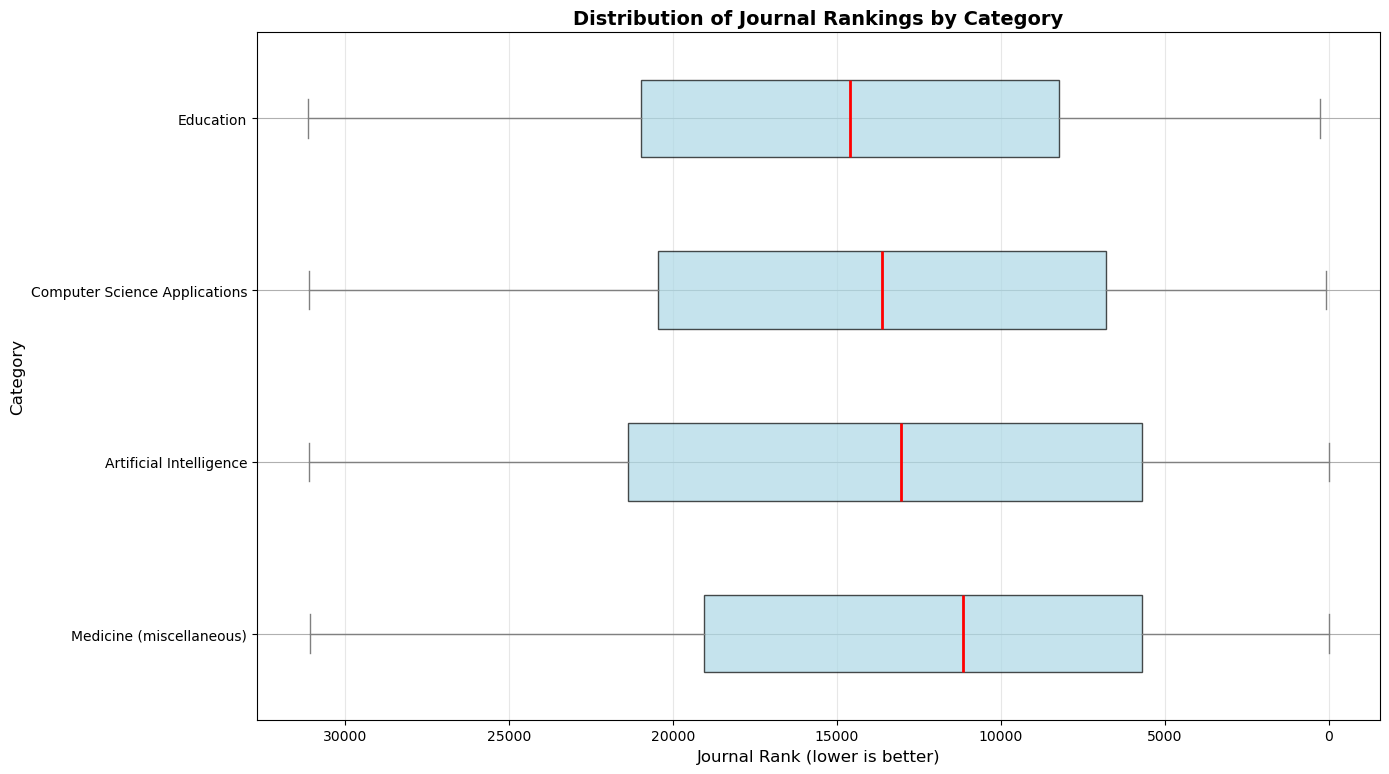


RANKING STATISTICS BY CATEGORY

Category                                 Min      Q1       Median   Q3       Max     
--------------------------------------------------------------------------------
Medicine (miscellaneous)                 2        5715     11155    19066    31063   
Artificial Intelligence                  10       5703     13044    21352    31105   
Computer Science Applications            86       6783     13620    20458    31098   
Education                                276      8224     14604    20963    31126   


/var/folders/c8/ypmvlrjd3r16wxnxns1rljyr0000gn/T/ipykernel_54671/4190051197.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_filtered[['Category', 'Rank']].groupby('Category').describe()


Rank                                    \
                                count          mean          std    min   
Category                                                                  
Medicine (miscellaneous)       2524.0  12752.671949  8548.623718    2.0   
Artificial Intelligence         441.0  13787.888889  9066.579265   10.0   
Computer Science Applications   952.0  13933.715336  8464.326534   86.0   
Education                      1597.0  14736.200376  8097.037229  276.0   

                                                                    
                                   25%      50%       75%      max  
Category                                                            
Medicine (miscellaneous)       5714.75  11155.0  19065.50  31063.0  
Artificial Intelligence        5703.00  13044.0  21352.00  31105.0  
Computer Science Applications  6783.00  13619.5  20458.25  31098.0  
Education                      8224.00  14604.0  20963.00  31126.0

In [30]:
plot_ranking_boxplot_by_category(rankings_exploded, 
    categories=[
        'Computer Science Applications',
        'Medicine (miscellaneous)',
        'Artificial Intelligence',
        'Education'
    ])

In [33]:
import pandas as pd

# Step 4: Query Functions for Easy Data Access

def get_top_journals_by_category(df_exploded, category, n=10, quartile=None):
    """
    Get top N journals in a specific category, optionally filtered by quartile
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe with Category, Rank, and Quartile columns
    category : str
        Category name (e.g., 'Computer Science Applications')
    n : int
        Number of top journals to return
    quartile : str, optional
        Filter by quartile: 'Q1', 'Q2', 'Q3', or 'Q4'. If None, returns all.
    
    Returns:
    --------
    pandas DataFrame
        Top N journals sorted by rank
    """
    # Filter by category
    df_filtered = df_exploded[df_exploded['Category'] == category].copy()
    
    if df_filtered.empty:
        print(f"No journals found for category: '{category}'")
        print("\nDid you mean one of these?")
        # Suggest similar categories
        all_categories = df_exploded['Category'].unique()
        similar = [cat for cat in all_categories if category.lower() in cat.lower()]
        for cat in similar[:5]:
            print(f"  - {cat}")
        return pd.DataFrame()
    
    # Filter by quartile if specified
    if quartile:
        df_filtered = df_filtered[df_filtered['Quartile'] == quartile.upper()]
        if df_filtered.empty:
            print(f"No {quartile} journals found in category: '{category}'")
            return pd.DataFrame()
    
    # Sort by rank and get top N
    df_top = df_filtered.sort_values('Rank').head(n)
    
    # Select relevant columns for display
    display_columns = [
        'Rank', 'Title', 'Quartile', 'SJR', 'Country', 
        'Publisher', 'Open Access', 'H index'
    ]
    
    # Only include columns that exist
    display_columns = [col for col in display_columns if col in df_top.columns]
    
    return df_top[display_columns].reset_index(drop=True)


def get_q1_journals(df_exploded, category):
    """
    Get all Q1 journals in a specific category
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    category : str
        Category name
    
    Returns:
    --------
    pandas DataFrame
        All Q1 journals in the category, sorted by rank
    """
    return get_top_journals_by_category(df_exploded, category, n=10000, quartile='Q1')


def search_categories(df_exploded, search_term):
    """
    Search for categories containing a specific term
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    search_term : str
        Term to search for (case-insensitive)
    
    Returns:
    --------
    list
        List of matching category names with journal counts
    """
    all_categories = df_exploded['Category'].value_counts()
    
    matching = all_categories[
        all_categories.index.str.contains(search_term, case=False, na=False)
    ]
    
    print(f"\nFound {len(matching)} categories matching '{search_term}':\n")
    print(f"{'Category':<50} {'# Journals':<12}")
    print("-" * 62)
    
    for cat, count in matching.items():
        print(f"{cat:<50} {count:<12}")
    
    return matching.index.tolist()


def get_journal_categories(df_exploded, journal_title):
    """
    Get all categories that a specific journal belongs to,
    and include the journal's rank within each category (position / total).
    """
    # Search for journal (case-insensitive, partial match)
    df_journal = df_exploded[
        df_exploded['Title'].str.contains(journal_title, case=False, na=False)
    ].copy()
    
    if df_journal.empty:
        print(f"No journal found matching: '{journal_title}'")
        return pd.DataFrame()
    
    # Get unique journals that matched
    unique_journals = df_journal['Title'].unique()
    
    if len(unique_journals) > 1:
        print(f"Found {len(unique_journals)} journals matching '{journal_title}':")
        for i, title in enumerate(unique_journals[:10], 1):
            print(f"  {i}. {title}")
        print("\nShowing results for first match. Use exact title for specific journal.")
        df_journal = df_journal[df_journal['Title'] == unique_journals[0]]
    
    # Display journal info
    journal_info = df_journal.iloc[0]
    journal_name = journal_info['Title']
    print("\n" + "=" * 80)
    print(f"JOURNAL: {journal_name}")
    print("=" * 80)
    print(f"Overall Rank: {journal_info.get('Rank')}")
    print(f"Country: {journal_info.get('Country')}")
    print(f"Publisher: {journal_info.get('Publisher')}")
    print(f"SJR: {journal_info.get('SJR')}")
    print(f"H-index: {journal_info.get('H index')}")
    
    # Show categories and compute rank within each category
    print(f"\nCategories ({len(df_journal)}):")
    print("-" * 80)
    
    # Ensure Category column exists and drop NA categories
    categories_df = df_journal[['Category', 'Quartile']].dropna(subset=['Category']).copy()
    categories_df = categories_df.sort_values('Quartile')
    
    # Add per-category ranking info
    ranks_in_category = []
    totals_in_category = []
    pct_in_category = []
    
    for idx, row in categories_df.iterrows():
        cat = row['Category']
        # all journals in this category (exclude rows with missing Rank)
        df_cat = df_exploded[(df_exploded['Category'] == cat) & df_exploded['Rank'].notna()].copy()
        df_cat = df_cat.sort_values('Rank').reset_index(drop=True)
        total = len(df_cat)
        totals_in_category.append(total)
        # find position(s) of this journal within the category
        pos = df_cat.index[df_cat['Title'] == journal_name].tolist()
        if pos:
            rank_pos = pos[0] + 1  # 1-based position
        else:
            # If exact title not found (title variants), try partial match
            matches = df_cat['Title'].str.contains(journal_name, case=False, na=False)
            pos2 = df_cat.index[matches].tolist()
            rank_pos = (pos2[0] + 1) if pos2 else None
        ranks_in_category.append(rank_pos)
        pct_in_category.append((rank_pos / total * 100) if (rank_pos and total) else None)
    
    categories_df = categories_df.reset_index(drop=True)
    categories_df['Category_Rank'] = ranks_in_category
    categories_df['Category_Total'] = totals_in_category
    categories_df['Category_Rank_Pct'] = [f"{p:.1f}%" if p is not None else None for p in pct_in_category]
    
    # Print nicely
    for idx, row in categories_df.iterrows():
        rank_txt = f"{int(row['Category_Rank'])}/{int(row['Category_Total'])}" if row['Category_Rank'] else "N/A"
        pct_txt = row['Category_Rank_Pct'] or ""
        print(f"  {row['Category']:<50} {row['Quartile']:<4}  Rank in category: {rank_txt} {pct_txt}")
    
    return categories_df

def get_category_summary(df_exploded, category):
    """
    Get comprehensive summary statistics for a category
    
    Parameters:
    -----------
    df_exploded : pandas DataFrame
        Exploded dataframe
    category : str
        Category name
    
    Returns:
    --------
    dict
        Dictionary containing summary statistics
    """
    df_cat = df_exploded[df_exploded['Category'] == category].copy()
    
    if df_cat.empty:
        print(f"No data found for category: '{category}'")
        return {}
    
    summary = {
        'category': category,
        'total_journals': len(df_cat),
        'q1_journals': len(df_cat[df_cat['Quartile'] == 'Q1']),
        'q2_journals': len(df_cat[df_cat['Quartile'] == 'Q2']),
        'q3_journals': len(df_cat[df_cat['Quartile'] == 'Q3']),
        'q4_journals': len(df_cat[df_cat['Quartile'] == 'Q4']),
        'best_rank': df_cat['Rank'].min(),
        'worst_rank': df_cat['Rank'].max(),
        'median_rank': df_cat['Rank'].median(),
        'top_journal': df_cat.loc[df_cat['Rank'].idxmin(), 'Title']
    }
    
    print("\n" + "=" * 80)
    print(f"CATEGORY SUMMARY: {category}")
    print("=" * 80)
    print(f"\nTotal Journals: {summary['total_journals']}")
    print(f"\nQuartile Distribution:")
    print(f"  Q1: {summary['q1_journals']} ({summary['q1_journals']/summary['total_journals']*100:.1f}%)")
    print(f"  Q2: {summary['q2_journals']} ({summary['q2_journals']/summary['total_journals']*100:.1f}%)")
    print(f"  Q3: {summary['q3_journals']} ({summary['q3_journals']/summary['total_journals']*100:.1f}%)")
    print(f"  Q4: {summary['q4_journals']} ({summary['q4_journals']/summary['total_journals']*100:.1f}%)")
    print(f"\nRanking Statistics:")
    print(f"  Best Rank: {summary['best_rank']}")
    print(f"  Median Rank: {summary['median_rank']:.0f}")
    print(f"  Worst Rank: {summary['worst_rank']}")
    print(f"\nTop Journal: {summary['top_journal']} (Rank #{summary['best_rank']})")
    
    return summary


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

print("=" * 80)
print("STEP 4: QUERY FUNCTIONS - COMPLETE CODE")
print("=" * 80)
print("\nAvailable functions:")
print("\n1. get_top_journals_by_category(df, category, n=10, quartile=None)")
print("   - Get top N journals in a category")
print("\n2. get_q1_journals(df, category)")
print("   - Get all Q1 journals in a category")
print("\n3. search_categories(df, search_term)")
print("   - Search for categories by keyword")
print("\n4. get_journal_categories(df, journal_title)")
print("   - Find all categories a journal belongs to")
print("\n5. get_category_summary(df, category)")
print("   - Get comprehensive statistics for a category")
print("\n" + "=" * 80)
print("\nEXAMPLE USAGE:")
print("=" * 80)
print("""
# Get top 10 journals in Computer Science Applications
top_cs = get_top_journals_by_category(rankings_exploded, 
    'Computer Science Applications', n=10)
print(top_cs)

# Get only Q1 journals in a category
top_q1 = get_top_journals_by_category(rankings_exploded, 
    'Artificial Intelligence', n=20, quartile='Q1')

# Get ALL Q1 journals in a category
all_q1 = get_q1_journals(rankings_exploded, 'Medicine (miscellaneous)')

# Search for categories
search_categories(rankings_exploded, 'computer')
search_categories(rankings_exploded, 'medicine')

# Find what categories a journal belongs to
get_journal_categories(rankings_exploded, 'Nature')
get_journal_categories(rankings_exploded, 'Science')

# Get category summary
summary = get_category_summary(rankings_exploded, 'Artificial Intelligence')
""")

STEP 4: QUERY FUNCTIONS - COMPLETE CODE

Available functions:

1. get_top_journals_by_category(df, category, n=10, quartile=None)
   - Get top N journals in a category

2. get_q1_journals(df, category)
   - Get all Q1 journals in a category

3. search_categories(df, search_term)
   - Search for categories by keyword

4. get_journal_categories(df, journal_title)
   - Find all categories a journal belongs to

5. get_category_summary(df, category)
   - Get comprehensive statistics for a category


EXAMPLE USAGE:

# Get top 10 journals in Computer Science Applications
top_cs = get_top_journals_by_category(rankings_exploded, 
    'Computer Science Applications', n=10)
print(top_cs)

# Get only Q1 journals in a category
top_q1 = get_top_journals_by_category(rankings_exploded, 
    'Artificial Intelligence', n=20, quartile='Q1')

# Get ALL Q1 journals in a category
all_q1 = get_q1_journals(rankings_exploded, 'Medicine (miscellaneous)')

# Search for categories
search_categories(rankings_explo

In [34]:
# summary = get_category_summary(rankings_exploded, 'Artificial Intelligence')
get_journal_categories(rankings_exploded, 'Journal of Documentation')



JOURNAL: Journal of Documentation
Overall Rank: 6931
Country: United Kingdom
Publisher: Emerald Group Publishing Ltd.
SJR: 0,787
H-index: 77

Categories (2):
--------------------------------------------------------------------------------
  Library and Information Sciences                   Q1    Rank in category: 44/291 15.1%
  Information Systems                                Q2    Rank in category: 113/481 23.5%


,Category,Quartile,Category_Rank,Category_Total,Category_Rank_Pct
0,Library and Information Sciences,Q1,44,291,15.1%
1,Information Systems,Q2,113,481,23.5%


In [46]:
top_cs =  get_top_journals_by_category(rankings_exploded, 
    'Education', n=10)
print(top_cs)

   Rank                                              Title Quartile    SJR  \
0   276   Computers and Education: Artificial Intelligence       Q1  5,217   
1   278                             Strategic Organization       Q1  5,210   
2   321                     Review of Educational Research       Q1  4,700   
3   361                      Educational Psychology Review       Q1  4,384   
4   417                         Research Synthesis Methods       Q1  4,020   
5   443  International Journal of Educational Technolog...       Q1  3,912   
6   466                        Educational Research Review       Q1  3,839   
7   598                            Computers and Education       Q1  3,343   
8   736                       Studies in Science Education       Q1  2,951   
9   750                               Developmental Review       Q1  2,920   

          Country                   Publisher Open Access  H index  
0     Netherlands               Elsevier B.V.         Yes       51  
1  

In [55]:
print(rankings['Issn'].isnull().value_counts())

Issn
False    31136
Name: count, dtype: int64


In [ ]:
# Okay LEt's now think about the best manner to integrate this data into our front end application. 

# USer must be able to select a category, Quartile or top ranking and based on this list an array of issn to filter on a query

In [56]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# Category Co-occurrence Analysis

def get_journal_category_groups(df_original):
    """
    Get all category combinations for each journal from the original dataframe
    
    Parameters:
    -----------
    df_original : pandas DataFrame
        Original dataframe (not exploded) with Categories column
    
    Returns:
    --------
    pandas DataFrame
        DataFrame with journal titles and their category lists
    """
    print("Extracting category groups from journals...")
    
    journal_categories = []
    
    for idx, row in df_original.iterrows():
        if pd.notna(row['Categories']):
            # Parse categories
            cats = row['Categories'].split(';')
            # Extract just category names (remove quartiles)
            category_names = []
            for cat in cats:
                cat = cat.strip()
                # Remove the (Q1), (Q2), etc. part
                import re
                match = re.search(r'^(.*?)\s*\(([Q][1-4])\)\s*$', cat)
                if match:
                    category_names.append(match.group(1).strip())
                else:
                    category_names.append(cat)
            
            journal_categories.append({
                'Title': row['Title'],
                'Rank': row['Rank'],
                'Categories': category_names,
                'Num_Categories': len(category_names)
            })
    
    df_journal_cats = pd.DataFrame(journal_categories)
    
    print(f"  ✓ Processed {len(df_journal_cats)} journals")
    print(f"  ✓ Average categories per journal: {df_journal_cats['Num_Categories'].mean():.2f}")
    
    return df_journal_cats


def analyze_category_pairs(df_journal_cats, min_frequency=10):
    """
    Find the most common pairs of categories that appear together
    
    Parameters:
    -----------
    df_journal_cats : pandas DataFrame
        DataFrame from get_journal_category_groups()
    min_frequency : int
        Minimum number of times a pair must appear
    
    Returns:
    --------
    pandas DataFrame
        Most common category pairs with frequencies
    """
    print(f"\nAnalyzing category pairs (min frequency: {min_frequency})...")
    
    pair_counts = {}
    
    for idx, row in df_journal_cats.iterrows():
        cats = row['Categories']
        if len(cats) >= 2:
            # Get all pairs of categories for this journal
            for cat1, cat2 in combinations(sorted(cats), 2):
                pair = (cat1, cat2)
                pair_counts[pair] = pair_counts.get(pair, 0) + 1
    
    # Convert to dataframe
    pairs_data = []
    for (cat1, cat2), count in pair_counts.items():
        if count >= min_frequency:
            pairs_data.append({
                'Category_1': cat1,
                'Category_2': cat2,
                'Frequency': count
            })
    
    df_pairs = pd.DataFrame(pairs_data)
    df_pairs = df_pairs.sort_values('Frequency', ascending=False)
    
    print(f"  ✓ Found {len(df_pairs)} category pairs with frequency >= {min_frequency}")
    
    return df_pairs


def analyze_category_triplets(df_journal_cats, min_frequency=5):
    """
    Find the most common triplets of categories that appear together
    
    Parameters:
    -----------
    df_journal_cats : pandas DataFrame
        DataFrame from get_journal_category_groups()
    min_frequency : int
        Minimum number of times a triplet must appear
    
    Returns:
    --------
    pandas DataFrame
        Most common category triplets with frequencies
    """
    print(f"\nAnalyzing category triplets (min frequency: {min_frequency})...")
    
    triplet_counts = {}
    
    for idx, row in df_journal_cats.iterrows():
        cats = row['Categories']
        if len(cats) >= 3:
            # Get all triplets of categories for this journal
            for cat1, cat2, cat3 in combinations(sorted(cats), 3):
                triplet = (cat1, cat2, cat3)
                triplet_counts[triplet] = triplet_counts.get(triplet, 0) + 1
    
    # Convert to dataframe
    triplets_data = []
    for (cat1, cat2, cat3), count in triplet_counts.items():
        if count >= min_frequency:
            triplets_data.append({
                'Category_1': cat1,
                'Category_2': cat2,
                'Category_3': cat3,
                'Frequency': count
            })
    
    df_triplets = pd.DataFrame(triplets_data)
    df_triplets = df_triplets.sort_values('Frequency', ascending=False)
    
    print(f"  ✓ Found {len(df_triplets)} category triplets with frequency >= {min_frequency}")
    
    return df_triplets


def display_top_combinations(df_pairs, df_triplets, top_n=20):
    """
    Display the most common category combinations
    
    Parameters:
    -----------
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    df_triplets : pandas DataFrame
        Category triplets from analyze_category_triplets()
    top_n : int
        Number of top combinations to show
    """
    print("\n" + "=" * 80)
    print(f"TOP {top_n} MOST COMMON CATEGORY PAIRS")
    print("=" * 80)
    
    for idx, row in df_pairs.head(top_n).iterrows():
        print(f"\n{row['Frequency']:4d} journals: {row['Category_1']}")
        print(f"              + {row['Category_2']}")
    
    print("\n" + "=" * 80)
    print(f"TOP {top_n} MOST COMMON CATEGORY TRIPLETS")
    print("=" * 80)
    
    for idx, row in df_triplets.head(top_n).iterrows():
        print(f"\n{row['Frequency']:4d} journals: {row['Category_1']}")
        print(f"              + {row['Category_2']}")
        print(f"              + {row['Category_3']}")


def plot_top_pairs(df_pairs, top_n=20, figsize=(12, 10)):
    """
    Visualize the most common category pairs
    
    Parameters:
    -----------
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    top_n : int
        Number of top pairs to show
    figsize : tuple
        Figure size
    """
    df_top = df_pairs.head(top_n).copy()
    
    # Create combined label
    df_top['Pair_Label'] = df_top['Category_1'] + '\n+ ' + df_top['Category_2']
    
    plt.figure(figsize=figsize)
    plt.barh(range(len(df_top)), df_top['Frequency'], color='steelblue')
    plt.yticks(range(len(df_top)), df_top['Pair_Label'], fontsize=9)
    plt.xlabel('Number of Journals', fontsize=12)
    plt.title(f'Top {top_n} Most Common Category Pairs', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


def suggest_category_groups(df_pairs, df_triplets, threshold_pairs=50, threshold_triplets=20):
    """
    Suggest category groups based on co-occurrence thresholds
    
    Parameters:
    -----------
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    df_triplets : pandas DataFrame
        Category triplets from analyze_category_triplets()
    threshold_pairs : int
        Minimum frequency for pair-based groups
    threshold_triplets : int
        Minimum frequency for triplet-based groups
    
    Returns:
    --------
    dict
        Suggested category groups
    """
    print("\n" + "=" * 80)
    print("SUGGESTED CATEGORY GROUPS")
    print("=" * 80)
    
    groups = {}
    group_id = 1
    
    # Strong triplets first
    strong_triplets = df_triplets[df_triplets['Frequency'] >= threshold_triplets]
    
    print(f"\nBased on triplets (threshold: {threshold_triplets}+ journals):")
    print("-" * 80)
    
    for idx, row in strong_triplets.head(15).iterrows():
        group_name = f"Group_{group_id}"
        categories = [row['Category_1'], row['Category_2'], row['Category_3']]
        groups[group_name] = {
            'categories': categories,
            'frequency': row['Frequency'],
            'type': 'triplet'
        }
        print(f"\n{group_name} ({row['Frequency']} journals):")
        for cat in categories:
            print(f"  - {cat}")
        group_id += 1
    
    # Strong pairs
    strong_pairs = df_pairs[df_pairs['Frequency'] >= threshold_pairs]
    
    print(f"\n\nBased on pairs (threshold: {threshold_pairs}+ journals):")
    print("-" * 80)
    
    for idx, row in strong_pairs.head(15).iterrows():
        group_name = f"Group_{group_id}"
        categories = [row['Category_1'], row['Category_2']]
        groups[group_name] = {
            'categories': categories,
            'frequency': row['Frequency'],
            'type': 'pair'
        }
        print(f"\n{group_name} ({row['Frequency']} journals):")
        for cat in categories:
            print(f"  - {cat}")
        group_id += 1
    
    return groups


def create_cooccurrence_matrix(df_journal_cats, top_n_categories=30):
    """
    Create a co-occurrence matrix and heatmap for top categories
    
    Parameters:
    -----------
    df_journal_cats : pandas DataFrame
        DataFrame from get_journal_category_groups()
    top_n_categories : int
        Number of top categories to include in matrix
    """
    print(f"\nCreating co-occurrence matrix for top {top_n_categories} categories...")
    
    # Get top categories by frequency
    all_cats = []
    for cats in df_journal_cats['Categories']:
        all_cats.extend(cats)
    
    cat_counts = pd.Series(all_cats).value_counts()
    top_cats = cat_counts.head(top_n_categories).index.tolist()
    
    # Create co-occurrence matrix
    n = len(top_cats)
    matrix = np.zeros((n, n))
    
    for idx, row in df_journal_cats.iterrows():
        cats = [c for c in row['Categories'] if c in top_cats]
        for i, cat1 in enumerate(top_cats):
            for j, cat2 in enumerate(top_cats):
                if i != j and cat1 in cats and cat2 in cats:
                    matrix[i][j] += 1
    
    # Create heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(matrix, xticklabels=top_cats, yticklabels=top_cats, 
                cmap='YlOrRd', annot=False, fmt='g', cbar_kws={'label': 'Co-occurrence Count'})
    plt.title(f'Category Co-occurrence Matrix (Top {top_n_categories} Categories)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=11)
    plt.ylabel('Category', fontsize=11)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(matrix, index=top_cats, columns=top_cats)


def analyze_category_pairing_behavior(df_journal_cats, df_pairs, min_journals=10):
    """
    Analyze how each category pairs with others:
    - Specialists: pair with few categories
    - Generalists: pair with many categories
    - Isolated: rarely pair with others
    
    Parameters:
    -----------
    df_journal_cats : pandas DataFrame
        DataFrame from get_journal_category_groups()
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    min_journals : int
        Minimum journals for a category to be analyzed
    
    Returns:
    --------
    pandas DataFrame
        Pairing behavior analysis for each category
    """
    print("\nAnalyzing category pairing behavior...")
    
    # Get all categories and their frequencies
    all_cats = []
    for cats in df_journal_cats['Categories']:
        all_cats.extend(cats)
    cat_counts = pd.Series(all_cats).value_counts()
    
    # Filter to categories with enough journals
    categories_to_analyze = cat_counts[cat_counts >= min_journals].index.tolist()
    
    behavior_data = []
    
    for category in categories_to_analyze:
        # Find all pairs involving this category
        pairs_with_cat = df_pairs[
            (df_pairs['Category_1'] == category) | 
            (df_pairs['Category_2'] == category)
        ].copy()
        
        # Get the other categories it pairs with
        other_cats = []
        pair_frequencies = []
        
        for idx, row in pairs_with_cat.iterrows():
            other_cat = row['Category_2'] if row['Category_1'] == category else row['Category_1']
            other_cats.append(other_cat)
            pair_frequencies.append(row['Frequency'])
        
        num_unique_pairs = len(other_cats)
        total_pairing_frequency = sum(pair_frequencies)
        avg_pairing_frequency = np.mean(pair_frequencies) if pair_frequencies else 0
        max_pairing_frequency = max(pair_frequencies) if pair_frequencies else 0
        
        # Calculate concentration ratio (how much is with top partner)
        concentration_ratio = max_pairing_frequency / total_pairing_frequency if total_pairing_frequency > 0 else 0
        
        # Classify behavior
        if num_unique_pairs == 0:
            behavior = "Isolated"
        elif num_unique_pairs <= 2:
            behavior = "Highly Specialized"
        elif num_unique_pairs <= 5:
            behavior = "Moderately Specialized"
        elif num_unique_pairs <= 10:
            behavior = "Moderately General"
        else:
            behavior = "Highly General"
        
        # If concentration ratio is high, it's focused
        if concentration_ratio > 0.5 and num_unique_pairs > 0:
            behavior += " (Focused)"
        
        behavior_data.append({
            'Category': category,
            'Total_Journals': cat_counts[category],
            'Num_Partner_Categories': num_unique_pairs,
            'Total_Pairings': total_pairing_frequency,
            'Avg_Pairing_Frequency': avg_pairing_frequency,
            'Max_Pairing_Frequency': max_pairing_frequency,
            'Concentration_Ratio': concentration_ratio,
            'Behavior_Type': behavior,
            'Top_Partner': other_cats[0] if other_cats else None
        })
    
    df_behavior = pd.DataFrame(behavior_data)
    df_behavior = df_behavior.sort_values('Num_Partner_Categories')
    
    print(f"  ✓ Analyzed {len(df_behavior)} categories")
    
    return df_behavior


def display_pairing_behavior_summary(df_behavior):
    """
    Display summary of category pairing behaviors
    
    Parameters:
    -----------
    df_behavior : pandas DataFrame
        Output from analyze_category_pairing_behavior()
    """
    print("\n" + "=" * 80)
    print("CATEGORY PAIRING BEHAVIOR SUMMARY")
    print("=" * 80)
    
    # Count by behavior type
    behavior_counts = df_behavior['Behavior_Type'].value_counts()
    
    print("\nBehavior Type Distribution:")
    print("-" * 80)
    for behavior, count in behavior_counts.items():
        print(f"  {behavior:<35} {count:>4} categories")
    
    # Show examples of each type
    print("\n" + "=" * 80)
    print("EXAMPLES BY BEHAVIOR TYPE")
    print("=" * 80)
    
    behavior_types = [
        "Isolated",
        "Highly Specialized",
        "Moderately Specialized", 
        "Moderately General",
        "Highly General"
    ]
    
    for behavior in behavior_types:
        # Get base behavior (without "Focused" suffix)
        df_type = df_behavior[df_behavior['Behavior_Type'].str.contains(behavior, regex=False)]
        
        if len(df_type) > 0:
            print(f"\n{behavior.upper()} ({len(df_type)} categories)")
            print("-" * 80)
            
            for idx, row in df_type.head(5).iterrows():
                print(f"\n  {row['Category']}")
                print(f"    - Total journals: {row['Total_Journals']}")
                print(f"    - Pairs with {row['Num_Partner_Categories']} other categories")
                if row['Top_Partner']:
                    print(f"    - Top partner: {row['Top_Partner']} ({row['Max_Pairing_Frequency']} journals)")
                print(f"    - Concentration: {row['Concentration_Ratio']:.1%}")


def find_strongly_linked_category_pairs(df_behavior, df_pairs, concentration_threshold=0.4):
    """
    Find categories that are strongly linked to specific partners
    (good candidates for grouping)
    
    Parameters:
    -----------
    df_behavior : pandas DataFrame
        Output from analyze_category_pairing_behavior()
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    concentration_threshold : float
        Minimum concentration ratio to consider "strongly linked"
    
    Returns:
    --------
    pandas DataFrame
        Strongly linked category pairs
    """
    print("\n" + "=" * 80)
    print("STRONGLY LINKED CATEGORY PAIRS")
    print(f"(Categories where >{concentration_threshold:.0%} of pairings are with 1-2 partners)")
    print("=" * 80)
    
    # Get focused/specialized categories
    focused_cats = df_behavior[
        (df_behavior['Concentration_Ratio'] >= concentration_threshold) &
        (df_behavior['Num_Partner_Categories'] <= 5)
    ].copy()
    
    strong_links = []
    
    for idx, row in focused_cats.iterrows():
        cat = row['Category']
        
        # Get its top pairs
        top_pairs = df_pairs[
            (df_pairs['Category_1'] == cat) | 
            (df_pairs['Category_2'] == cat)
        ].head(3)
        
        for _, pair in top_pairs.iterrows():
            partner = pair['Category_2'] if pair['Category_1'] == cat else pair['Category_1']
            
            strong_links.append({
                'Category_1': cat,
                'Category_2': partner,
                'Frequency': pair['Frequency'],
                'Cat1_Total_Journals': row['Total_Journals'],
                'Concentration': row['Concentration_Ratio']
            })
    
    df_strong_links = pd.DataFrame(strong_links)
    df_strong_links = df_strong_links.sort_values('Frequency', ascending=False)
    
    # Display
    print(f"\nFound {len(df_strong_links)} strong links:\n")
    
    for idx, row in df_strong_links.head(20).iterrows():
        print(f"{row['Frequency']:4d} journals: {row['Category_1']}")
        print(f"              + {row['Category_2']}")
        print(f"              (Concentration: {row['Concentration']:.1%})\n")
    
    return df_strong_links


def plot_pairing_behavior(df_behavior, figsize=(14, 8)):
    """
    Visualize category pairing behavior
    
    Parameters:
    -----------
    df_behavior : pandas DataFrame
        Output from analyze_category_pairing_behavior()
    figsize : tuple
        Figure size
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Distribution of number of partners
    ax1 = axes[0]
    partner_counts = df_behavior['Num_Partner_Categories'].value_counts().sort_index()
    ax1.bar(partner_counts.index, partner_counts.values, color='steelblue')
    ax1.set_xlabel('Number of Partner Categories', fontsize=11)
    ax1.set_ylabel('Number of Categories', fontsize=11)
    ax1.set_title('Distribution of Partner Categories', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Concentration ratio distribution
    ax2 = axes[1]
    ax2.hist(df_behavior['Concentration_Ratio'], bins=20, color='coral', edgecolor='black')
    ax2.set_xlabel('Concentration Ratio', fontsize=11)
    ax2.set_ylabel('Number of Categories', fontsize=11)
    ax2.set_title('Partner Concentration Distribution', fontsize=12, fontweight='bold')
    ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, label='High Concentration (>50%)')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def suggest_grouping_strategy(df_behavior, df_pairs):
    """
    Suggest a strategy for grouping categories based on their pairing behavior
    
    Parameters:
    -----------
    df_behavior : pandas DataFrame
        Output from analyze_category_pairing_behavior()
    df_pairs : pandas DataFrame
        Category pairs from analyze_category_pairs()
    """
    print("\n" + "=" * 80)
    print("SUGGESTED GROUPING STRATEGY")
    print("=" * 80)
    
    # Strategy 1: Group highly specialized categories with their top partners
    specialized = df_behavior[
        df_behavior['Behavior_Type'].str.contains('Specialized')
    ]
    
    print(f"\nSTRATEGY 1: Specialized Categories")
    print(f"Found {len(specialized)} specialized categories")
    print("These should be grouped with their 1-2 main partners:")
    print("-" * 80)
    
    for idx, row in specialized.head(10).iterrows():
        if row['Top_Partner']:
            print(f"\n  Group: {row['Category']} + {row['Top_Partner']}")
            print(f"    ({row['Max_Pairing_Frequency']} journals)")
    
    # Strategy 2: Leave isolated categories alone
    isolated = df_behavior[df_behavior['Behavior_Type'] == 'Isolated']
    
    print(f"\n\nSTRATEGY 2: Isolated Categories")
    print(f"Found {len(isolated)} isolated categories")
    print("These rarely pair with others - keep as standalone:")
    print("-" * 80)
    
    for idx, row in isolated.head(10).iterrows():
        print(f"  - {row['Category']} ({row['Total_Journals']} journals)")
    
    # Strategy 3: Generalist categories - create broader groups
    general = df_behavior[
        df_behavior['Behavior_Type'].str.contains('General')
    ]
    
    print(f"\n\nSTRATEGY 3: General Categories")
    print(f"Found {len(general)} general categories")
    print("These pair with many others - consider thematic grouping:")
    print("-" * 80)
    
    for idx, row in general.head(10).iterrows():
        print(f"  - {row['Category']} (pairs with {row['Num_Partner_Categories']} categories)")
    
    print("\n" + "=" * 80)


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

print("=" * 80)
print("CATEGORY CO-OCCURRENCE ANALYSIS")
print("=" * 80)
print("\nThis module analyzes which categories commonly appear together.")
print("\nUSAGE:")
print("=" * 80)
print("""
# COMPLETE WORKFLOW:

# Step 1: Extract category groups
journal_cats = get_journal_category_groups(rankings)

# Step 2: Analyze pairs and triplets
pairs = analyze_category_pairs(journal_cats, min_frequency=10)
triplets = analyze_category_triplets(journal_cats, min_frequency=5)

# Step 3: Analyze pairing behavior (NEW!)
behavior = analyze_category_pairing_behavior(journal_cats, pairs, min_journals=10)

# Step 4: Display behavior summary
display_pairing_behavior_summary(behavior)

# Step 5: Find strongly linked pairs
strong_links = find_strongly_linked_category_pairs(behavior, pairs, 
                                                    concentration_threshold=0.4)

# Step 6: Visualize behavior
plot_pairing_behavior(behavior)

# Step 7: Get grouping suggestions
suggest_grouping_strategy(behavior, pairs)

# Step 8: Optional - see all top combinations
display_top_combinations(pairs, triplets, top_n=20)
plot_top_pairs(pairs, top_n=20)

# Step 9: Optional - heatmap
matrix = create_cooccurrence_matrix(journal_cats, top_n_categories=30)

# UNDERSTANDING THE OUTPUT:
# - Isolated: Categories that rarely appear with others
# - Highly Specialized: Pair with 1-2 other categories only
# - Moderately Specialized: Pair with 3-5 other categories
# - Moderately General: Pair with 6-10 other categories  
# - Highly General: Pair with 10+ other categories
# - (Focused): When >50% of pairings are with top partner

# RECOMMENDED THRESHOLDS:
# - concentration_threshold=0.4: Categories where 40%+ pairings are with 1 partner
# - concentration_threshold=0.5: Very focused relationships (50%+)
# - min_journals=10: Only analyze categories with 10+ journals
""")

CATEGORY CO-OCCURRENCE ANALYSIS

This module analyzes which categories commonly appear together.

USAGE:

# COMPLETE WORKFLOW:

# Step 1: Extract category groups
journal_cats = get_journal_category_groups(rankings)

# Step 2: Analyze pairs and triplets
pairs = analyze_category_pairs(journal_cats, min_frequency=10)
triplets = analyze_category_triplets(journal_cats, min_frequency=5)

# Step 3: Analyze pairing behavior (NEW!)
behavior = analyze_category_pairing_behavior(journal_cats, pairs, min_journals=10)

# Step 4: Display behavior summary
display_pairing_behavior_summary(behavior)

# Step 5: Find strongly linked pairs
strong_links = find_strongly_linked_category_pairs(behavior, pairs, 
                                                    concentration_threshold=0.4)

# Step 6: Visualize behavior
plot_pairing_behavior(behavior)

# Step 7: Get grouping suggestions
suggest_grouping_strategy(behavior, pairs)

# Step 8: Optional - see all top combinations
display_top_combinations(pairs, tri

In [57]:
journal_cats = get_journal_category_groups(rankings)
pairs = analyze_category_pairs(journal_cats, min_frequency=10)
triplets = analyze_category_triplets(journal_cats, min_frequency=5)
behavior = analyze_category_pairing_behavior(journal_cats, pairs, min_journals=10)
display_pairing_behavior_summary(behavior)


Extracting category groups from journals...
  ✓ Processed 31136 journals
  ✓ Average categories per journal: 2.47

Analyzing category pairs (min frequency: 10)...
  ✓ Found 1936 category pairs with frequency >= 10

Analyzing category triplets (min frequency: 5)...
  ✓ Found 2671 category triplets with frequency >= 5

Analyzing category pairing behavior...
  ✓ Analyzed 300 categories

CATEGORY PAIRING BEHAVIOR SUMMARY

Behavior Type Distribution:
--------------------------------------------------------------------------------
  Highly General                       150 categories
  Moderately General                    61 categories
  Moderately Specialized                41 categories
  Highly Specialized (Focused)          25 categories
  Isolated                              16 categories
  Moderately Specialized (Focused)       6 categories
  Moderately General (Focused)           1 categories

EXAMPLES BY BEHAVIOR TYPE

ISOLATED (16 categories)
--------------------------------------

In [59]:
rankings.shape

(31136, 27)

In [60]:
rankings_exploded.shape

(76823, 29)